In [3]:
import pandas as pd
import re
import seaborn as sns

In [49]:
def read_results_file(fname):
  # Read and parse the file into a DataFrame
  data = []
  with open(file_path, 'r') as f:
      for line in f:
          # Split the line into key-value pairs and remove the trailing comma
          pairs = [item.strip().rstrip(',') for item in line.split(',')]
          # Convert the pairs into a dictionary
          row = {key_value.split('=')[0]: key_value.split('=')[1] for key_value in pairs if '=' in key_value}
          data.append(row)
  
  # Create the DataFrame
  df = pd.DataFrame(data)
  
  # Convert numeric columns to the appropriate type
  df = df.apply(pd.to_numeric, errors='ignore')
  return df

### Number of Background Clips

In [77]:
# File path
file_path = "experiment_data/num_clips_test_results.dat"
df = read_results_file(file_path)

num_clips_vals = [int(re.search(r'_(\d+)clips', s).group(1)) for s in df['train_set']]
df.insert(2, 'num_clips', value=num_clips_vals)
df

/var/folders/qb/jcjkm0nx4878vyqfjy786xdh0000gn/T/ipykernel_69355/990579863.py:16: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


,train_set,thresh,num_clips,fp_th0p99,tp_th0p99,fn_th0p99,fp_th0p95,tp_th0p95,fn_th0p95,false_detections,true_detections,false_rejections,loss,categorical_accuracy,precision_1,recall_1
0,sww_stride16_50clips_t1,0.07,50,5,47,3,9,48,2,47,49,1,0.2762,0.9657,0.9720,0.8552
1,sww_stride16_100clips_t1,0.44,100,33,48,2,57,48,2,111,49,1,0.2064,0.9715,0.9515,0.9045
2,sww_stride16_100clips_t1,0.48,100,18,48,2,39,48,2,83,49,1,0.1906,0.9705,0.9509,0.9013
3,sww_stride16_100clips_t1,0.50,100,24,45,5,43,47,3,94,48,2,0.1783,0.9728,0.9501,0.9124
4,sww_stride16_100clips_t2,0.28,100,3,45,5,14,46,4,95,48,2,0.3440,0.9544,0.9566,0.8119
5,sww_stride16_100clips_t2,0.23,100,7,47,3,12,47,3,63,48,2,0.3266,0.9555,0.9614,0.8112
6,sww_stride16_100clips_t2,0.24,100,11,43,7,14,46,4,80,49,1,0.3128,0.9562,0.9617,0.8169
7,sww_stride16_100clips_t3,0.59,100,4,42,8,6,45,5,40,46,4,0.3026,0.9562,0.9458,0.8308
8,sww_stride16_100clips_t3,0.40,100,11,45,5,17,45,5,55,48,2,0.3305,0.9574,0.9554,0.8276
9,sww_stride16_100clips_t3,0.44,100,6,44,6,11,45,5,26,45,5,0.3768,0.9546,0.9516,0.8155


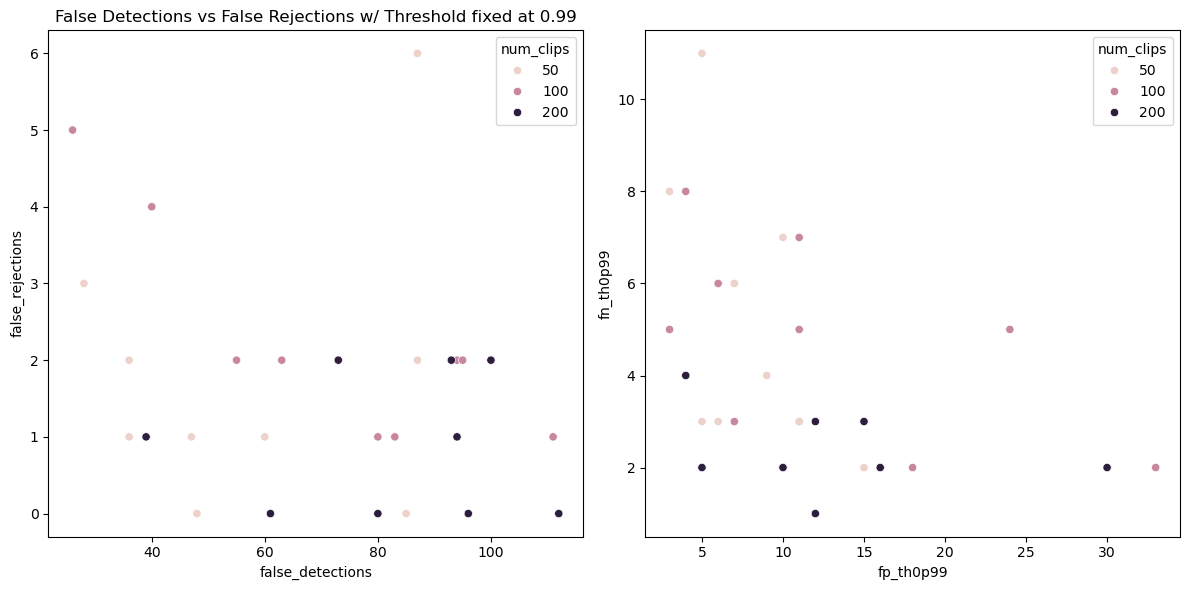

In [78]:
plt.figure(figsize=(12,6))
hAx1 = plt.subplot(1,2,1)
sns.scatterplot(data=df, ax=hAx1, x='false_detections', y='false_rejections', hue='num_clips')
hAx1.set_title(f"False Detections vs False Rejections w/ Threshold for Precision=0.95")
hAx2 = plt.subplot(1,2,2)
sns.scatterplot(data=df, ax=hAx2, x='fp_th0p99', y='fn_th0p99', hue='num_clips')
hAx1.set_title(f"False Detections vs False Rejections w/ Threshold for Precision=0.95")
hAx1.set_title(f"False Detections vs False Rejections w/ Threshold fixed at 0.99")

# hAx.set_xlim([0,40])
plt.tight_layout()

The bottom line takeaway from these results is that, at least at the current values for other parameters, there is no clear pattern of improved performance for different numbers of background clips in the range [50,100,200].

### Minimum SNR Level

In [91]:
# File path
file_path = "experiment_data/snr_results_5jan2024a.dat"
df = read_results_file(file_path)

df.insert(2, 'num_clips', value=50)
snr_levels = [0.1, 0.1, 0.1, 0.2, 0.2, 0.2, 0.5, 0.5, 0.5, 1.0, 1.0, 1.0]
df.insert(3, 'snr_val', value=snr_levels)

df

/var/folders/qb/jcjkm0nx4878vyqfjy786xdh0000gn/T/ipykernel_69355/990579863.py:16: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


,train_set,thresh,num_clips,snr_val,sparse0p1,sparse1p0,sparse2p0,fp_th0p99,tp_th0p99,fn_th0p99,fp_th0p95,tp_th0p95,fn_th0p95,false_detections,true_detections,false_rejections,loss,categorical_accuracy,precision_1,recall_1
0,ad-hoc,0.62,50,0.1,0.36,3.73,7.44,3,45,5,7,45,5,23,46,4,0.3272,0.9524,0.9449,0.8097
1,ad-hoc,0.60,50,0.1,0.40,4.15,8.19,3,44,6,10,45,5,18,48,2,0.2287,0.9657,0.9462,0.8870
2,ad-hoc,0.24,50,0.1,0.38,3.76,7.49,15,45,5,31,46,4,105,49,1,0.4484,0.9486,0.9628,0.7772
3,ad-hoc,0.80,50,0.2,0.42,4.29,8.46,9,48,2,16,48,2,22,48,2,0.3829,0.9521,0.9373,0.8187
4,ad-hoc,0.03,50,0.2,0.40,3.98,8.00,14,43,7,17,43,7,77,49,1,0.4264,0.9507,0.9744,0.7750
5,ad-hoc,0.06,50,0.2,0.40,4.00,7.97,7,44,6,18,46,4,117,48,2,0.7441,0.9190,0.9719,0.8666
6,ad-hoc,0.81,50,0.5,0.43,4.33,8.50,14,48,2,24,49,1,39,50,0,0.3837,0.9527,0.9356,0.8680
7,ad-hoc,0.09,50,0.5,0.43,4.39,8.73,18,48,2,24,48,2,90,50,0,0.1290,0.9810,0.9741,0.9299
8,ad-hoc,0.99,50,0.5,0.42,4.32,8.48,36,49,1,47,50,0,36,49,1,0.2772,0.9555,0.8993,0.9067
9,ad-hoc,0.12,50,1.0,0.40,3.97,7.83,11,46,4,19,46,4,67,48,2,0.1263,0.9803,0.9671,0.9356


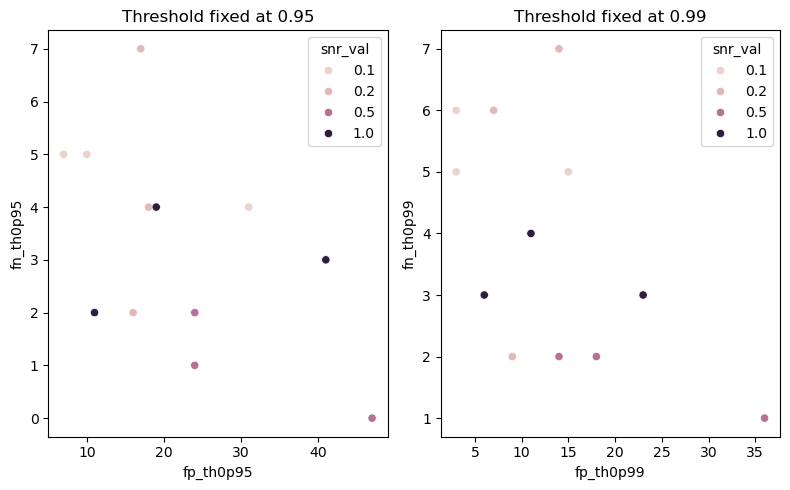

In [104]:
plt.figure(figsize=(8,5))
hAx1 = plt.subplot(1,2,1)
sns.scatterplot(data=df, ax=hAx1, x='fp_th0p95', y='fn_th0p95', hue='snr_val')
hAx1.set_title(f"Threshold fixed at 0.95")
hAx2 = plt.subplot(1,2,2)
sns.scatterplot(data=df, ax=hAx2, x='fp_th0p99', y='fn_th0p99', hue='snr_val')
hAx2.set_title(f"Threshold fixed at 0.99")

# hAx.set_xlim([0,40])
plt.tight_layout()

<Axes: xlabel='loss', ylabel='sparse1p0'>

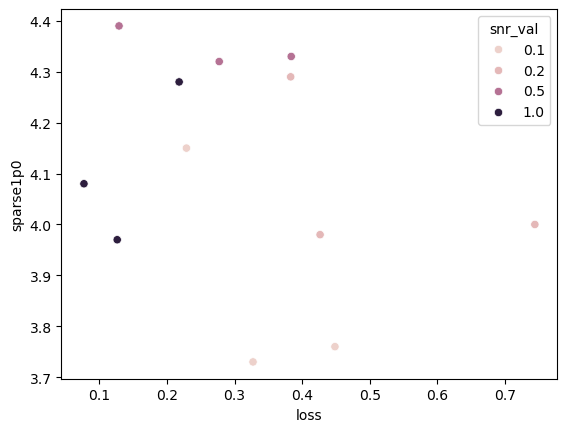

In [101]:
# hAx1 = plt.gca()
sns.scatterplot(data=df, x='loss', y='sparse1p0', hue='snr_val')


The effect of SNR value during training here is not clear.  There's a slight pattern of lower SNRs giving fewer false positives, but it's not a strong one.

In this experiment, it looks like there is a very small effect wherein training on lower SNR values results in lower sparsity, though there is no reason to expect any significant sparsity here, because there is no L2 or L1 regularization, and the effect is very small -- all runs had sparsity at the 1% level in the range of 3.7-4.4%.

### Model Size Test 

In [133]:
# File path
file_path = "experiment_data/model_test_s16_results.dat"
df16 = read_results_file(file_path)
df16["train_set"] = "sww_stride16.0_50clips_snr0.1_t1"
df16.insert(2, 'num_clips', value=50)
df16['num_params'][3:]=[44299, 44299, 44299, 119883, 119883, 119883, 376843, 376843, 376843, 522763, 522763, 522763]

file_path = "experiment_data/model_test_s32_results.dat"
df32 = read_results_file(file_path)
df32["train_set"] = "sww_stride32.0_50clips_snr0.1_t1"
df32.insert(2, 'num_clips', value=50)
num_params_s32 = [46875, 46875, 46875, 44235, 44235, 44235, 119755, 119755, 119755, 376587, 376587, 376587, 522507, 522507, 522507]
df32.insert(19, 'num_params', value=num_params_s32)

df = pd.concat([df16, df32], ignore_index=True)
df


/var/folders/qb/jcjkm0nx4878vyqfjy786xdh0000gn/T/ipykernel_69355/990579863.py:16: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')
/var/folders/qb/jcjkm0nx4878vyqfjy786xdh0000gn/T/ipykernel_69355/1324109014.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this

,trial,rep,num_clips,model_config,snr_val,timestamp,train_set,thresh,sparse0p1,sparse1p0,...,win_size,win_stride,num_params,false_detections,true_detections,false_rejections,loss,categorical_accuracy,precision_1,recall_1
0,1,1,50,model_config_basic_s16.json,0.1,Mon Jan 6 14:29:14 UTC 2025,sww_stride16.0_50clips_snr0.1_t1,0.25,0.56,3.49,...,32.0,16.0,50843.0,97,50,0,0.5150,0.9385,0.9612,0.7257
1,2,2,50,model_config_basic_s16.json,0.1,Mon Jan 6 14:40:35 UTC 2025,sww_stride16.0_50clips_snr0.1_t1,0.43,0.52,3.55,...,32.0,16.0,50843.0,65,47,3,0.5523,0.9363,0.9536,0.7210
2,3,3,50,model_config_basic_s16.json,0.1,Mon Jan 6 14:50:59 UTC 2025,sww_stride16.0_50clips_snr0.1_t1,0.39,0.52,3.43,...,32.0,16.0,50843.0,93,50,0,0.5163,0.9376,0.9563,0.7285
3,4,1,50,model_config_causal_1_s16.json,0.1,Mon Jan 6 03:44:58 UTC 2025,sww_stride16.0_50clips_snr0.1_t1,0.50,0.37,3.00,...,32.0,16.0,44299.0,71,48,2,0.3186,0.9396,0.9507,0.7386
4,5,2,50,model_config_causal_1_s16.json,0.1,Mon Jan 6 03:58:38 UTC 2025,sww_stride16.0_50clips_snr0.1_t1,0.55,0.31,2.96,...,32.0,16.0,44299.0,63,49,1,0.2931,0.9441,0.9473,0.7650
5,6,3,50,model_config_causal_1_s16.json,0.1,Mon Jan 6 04:12:06 UTC 2025,sww_stride16.0_50clips_snr0.1_t1,0.43,0.26,3.12,...,32.0,16.0,44299.0,69,48,2,0.3640,0.9374,0.9545,0.7271
6,7,1,50,model_config_causal_2_s16.json,0.1,Mon Jan 6 04:24:43 UTC 2025,sww_stride16.0_50clips_snr0.1_t1,0.46,0.38,3.20,...,32.0,16.0,119883.0,97,49,1,0.3713,0.9425,0.9537,0.7514
7,8,2,50,model_config_causal_2_s16.json,0.1,Mon Jan 6 04:38:26 UTC 2025,sww_stride16.0_50clips_snr0.1_t1,0.40,0.36,3.16,...,32.0,16.0,119883.0,112,49,1,0.4504,0.9381,0.9547,0.7310
8,9,3,50,model_config_causal_2_s16.json,0.1,Mon Jan 6 04:52:12 UTC 2025,sww_stride16.0_50clips_snr0.1_t1,0.58,0.35,3.17,...,32.0,16.0,119883.0,74,49,1,0.4647,0.9400,0.9467,0.7439
9,10,1,50,model_config_causal_3_s16.json,0.1,Mon Jan 6 05:06:21 UTC 2025,sww_stride16.0_50clips_snr0.1_t1,0.66,0.39,3.96,...,32.0,16.0,376843.0,79,49,1,0.5685,0.9379,0.9464,0.7386


In [154]:
sns.scatterplot

<function seaborn.relational.scatterplot(data=None, *, x=None, y=None, hue=None, size=None, style=None, palette=None, hue_order=None, hue_norm=None, sizes=None, size_order=None, size_norm=None, markers=True, style_order=None, legend='auto', ax=None, **kwargs)>

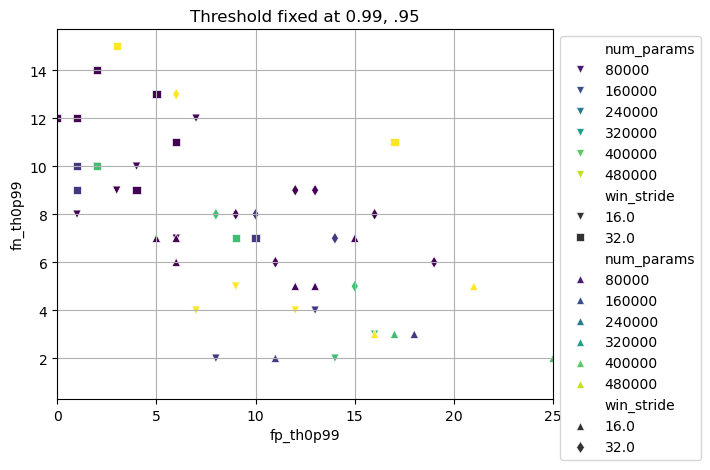

In [155]:
hAx2 = plt.gca()
sns.scatterplot(data=df, ax=hAx2, x='fp_th0p99', y='fn_th0p99', 
                hue='num_params', style='win_stride', markers={16.0: "v", 32.0: "s"}, palette="viridis")

sns.scatterplot(data=df, ax=hAx2, x='fp_th0p95', y='fn_th0p95', 
                hue='num_params', style='win_stride', markers={16.0: "^", 32.0: "d"}, palette="viridis")
hAx2.set_xlim([0,25])
hAx2.grid(True)
hAx2.set_title(f"Threshold fixed at 0.99, .95")
sns.move_legend(hAx2, "upper left", bbox_to_anchor=(1, 1))

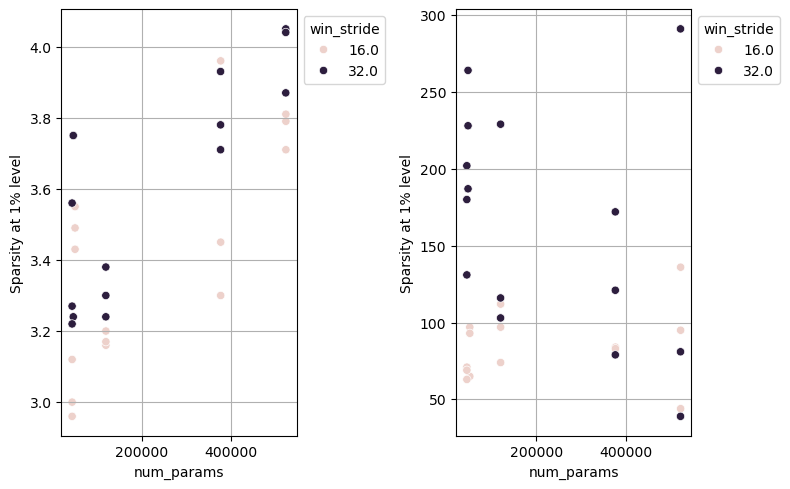

In [152]:
plt.figure(figsize=(8,5))
hAx1 = plt.subplot(1,2,1)
sns.scatterplot(data=df, ax=hAx1, x='num_params', y='sparse1p0', hue='win_stride')
hAx1.grid(True)
hAx1.set_ylabel("Sparsity at 1% level")
sns.move_legend(hAx1, "upper left", bbox_to_anchor=(1, 1))


hAx2 = plt.subplot(1,2,2)
sns.scatterplot(data=df, ax=hAx2, x='num_params', y='false_detections', hue='win_stride')
hAx2.grid(True)
hAx2.set_ylabel("Sparsity at 1% level")
sns.move_legend(hAx2, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

### L2 Experiment (old)

In [156]:
# File path
file_path = "experiment_data/l2_summary_20dec2024.csv"
df = read_results_file(file_path)
# df["train_set"] = "sww_stride16.0_50clips_snr0.1_t1"
# df.insert(2, 'num_clips', value=50)
# df['num_params'][3:]=[44299, 44299, 44299, 119883, 119883, 119883, 376843, 376843, 376843, 522763, 522763, 522763]

df

/var/folders/qb/jcjkm0nx4878vyqfjy786xdh0000gn/T/ipykernel_69355/990579863.py:16: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


,false_detections,true_detections,false_rejections,loss,accuracy,precision,recall,recall_at_pr90,L2
0,16,47,3,0.5542,0.9376,0.9860,0.6549,0.7840,0.00000
1,20,49,1,0.1224,0.9753,0.9841,0.8659,0.9467,0.00100
2,16,49,1,0.1232,0.9749,0.9911,0.8391,0.9474,0.00100
3,23,49,1,0.1096,0.9783,0.9898,0.8684,0.9524,0.00100
4,23,49,1,0.1131,0.9747,0.9803,0.8895,0.9456,0.00100
5,23,49,1,0.1416,0.9684,0.9779,0.8552,0.9253,0.00100
6,23,49,1,0.1261,0.9738,0.9780,0.8737,0.9435,0.00100
7,23,49,1,0.2372,0.9599,0.9908,0.8054,0.9185,0.00100
8,23,49,1,0.1755,0.9633,0.9813,0.8065,0.9070,0.00100
9,23,49,1,0.1186,0.9758,0.9833,0.8648,0.9542,0.00100


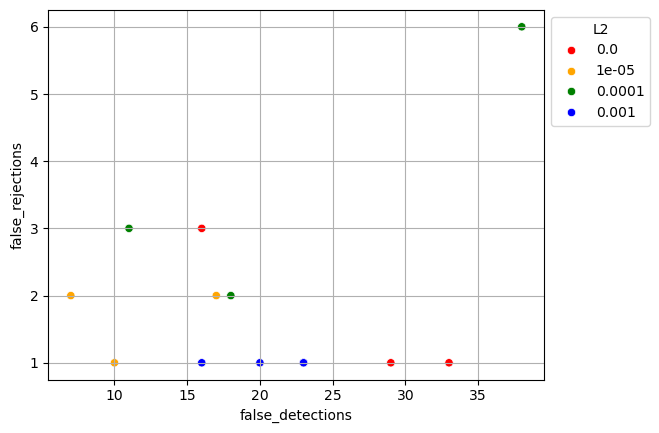

In [165]:
# hAx1 = plt.subplot(1,2,1)
hAx1= plt.gca()
sns.scatterplot(data=df, ax=hAx1, x='false_detections', y='false_rejections', hue='L2', palette=["red", "orange", "green", "blue"])
hAx1.grid(True)
sns.move_legend(hAx1, "upper left", bbox_to_anchor=(1, 1))


This dataset needs to have sparsity values extracted to be very informative.

### L2 Experiment 6 Jan 2025

In [188]:
file_path = "experiment_data/l2_results_1.dat"
df = read_results_file(file_path)
df["train_set"] = "sww_stride16.0_50clips_snr0.1_t1"
# df["num_params"] = 522763
df.insert(2, 'num_clips', value=50)
df.insert(2, "l2_log", value=np.log10(df["l2"]+1e-9))


df

/var/folders/qb/jcjkm0nx4878vyqfjy786xdh0000gn/T/ipykernel_69355/990579863.py:16: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


,trial,rep,l2_log,num_clips,model_config,snr_val,timestamp,train_set,thresh,sparse0p1,...,win_stride,num_params,false_detections,true_detections,false_rejections,loss,categorical_accuracy,precision_1,recall_1,l2
0,1,1,-9.000000,50,model_config_causal_4_s16.json,0.1,Mon Jan 6 15:44:57 UTC 2025,sww_stride16.0_50clips_snr0.1_t1,0.25,0.42,...,16.0,522763,183,49,1,0.4652,0.9411,0.9618,0.7386,0.00000
1,2,2,-9.000000,50,model_config_causal_4_s16.json,0.1,Mon Jan 6 16:02:02 UTC 2025,sww_stride16.0_50clips_snr0.1_t1,0.52,0.40,...,16.0,522763,51,47,3,0.5344,0.9364,0.9490,0.7257,0.00000
2,3,3,-9.000000,50,model_config_causal_4_s16.json,0.1,Mon Jan 6 16:18:24 UTC 2025,sww_stride16.0_50clips_snr0.1_t1,0.43,0.38,...,16.0,522763,56,49,1,0.4565,0.9404,0.9537,0.7436,0.00000
3,4,1,-4.999957,50,model_config_causal_4_s16.json,0.1,Mon Jan 6 16:35:24 UTC 2025,sww_stride16.0_50clips_snr0.1_t1,0.36,85.96,...,16.0,522763,65,47,3,0.3717,0.9441,0.9604,0.7539,0.00001
4,5,2,-4.999957,50,model_config_causal_4_s16.json,0.1,Mon Jan 6 16:52:53 UTC 2025,sww_stride16.0_50clips_snr0.1_t1,0.61,85.68,...,16.0,522763,29,48,2,0.3553,0.9420,0.9433,0.7611,0.00001
5,6,3,-4.999957,50,model_config_causal_4_s16.json,0.1,Mon Jan 6 17:10:09 UTC 2025,sww_stride16.0_50clips_snr0.1_t1,0.34,85.91,...,16.0,522763,149,49,1,0.3565,0.9427,0.9601,0.7486,0.00001
6,7,1,-3.999996,50,model_config_causal_4_s16.json,0.1,Mon Jan 6 17:27:39 UTC 2025,sww_stride16.0_50clips_snr0.1_t1,0.45,87.59,...,16.0,522763,40,48,2,0.3940,0.9433,0.9527,0.7564,0.00010
7,8,2,-3.999996,50,model_config_causal_4_s16.json,0.1,Mon Jan 6 17:45:08 UTC 2025,sww_stride16.0_50clips_snr0.1_t1,0.62,85.86,...,16.0,522763,50,47,3,0.3713,0.9431,0.9454,0.7618,0.00010
8,9,3,-3.999996,50,model_config_causal_4_s16.json,0.1,Mon Jan 6 18:02:37 UTC 2025,sww_stride16.0_50clips_snr0.1_t1,0.49,87.88,...,16.0,522763,57,48,2,0.3702,0.9437,0.9516,0.7593,0.00010
9,10,1,-3.000000,50,model_config_causal_4_s16.json,0.1,Mon Jan 6 18:19:53 UTC 2025,sww_stride16.0_50clips_snr0.1_t1,0.35,87.01,...,16.0,522763,50,50,0,0.3743,0.9411,0.9570,0.7403,0.00100


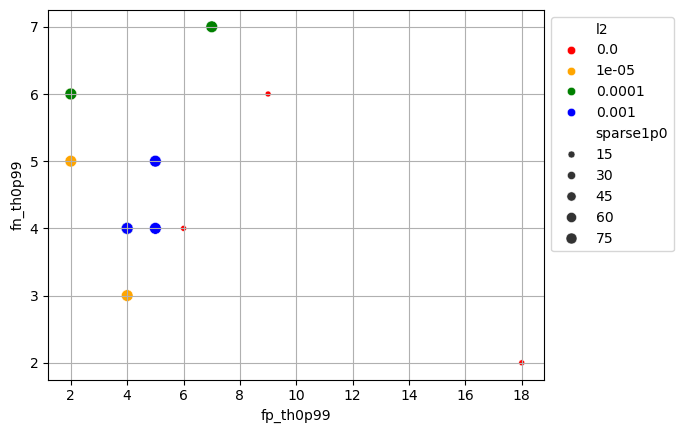

In [189]:
# hAx1 = plt.subplot(1,2,1)
hAx1= plt.gca()
sns.scatterplot(data=df, ax=hAx1, x='fp_th0p99', y='fn_th0p99', hue='l2', 
                palette=["red", "orange", "green", "blue"],
                size="sparse1p0")
hAx1.grid(True)
sns.move_legend(hAx1, "upper left", bbox_to_anchor=(1, 1))


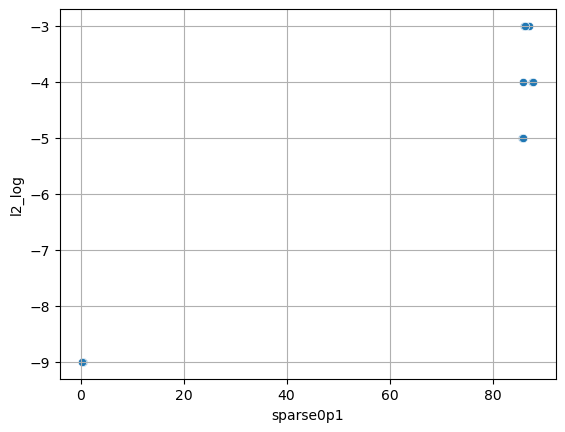

In [191]:
hAx1= plt.gca()
sns.scatterplot(data=df, ax=hAx1, x='sparse0p1', y='l2_log')
hAx1.grid(True)
# sns.move_legend(hAx1, "upper left", bbox_to_anchor=(1, 1))